<center>
<h1> Laboratorio PyCaret </h1>

<b> John González </b>

30 de septiembre de 2023
<p>
<img src='https://raw.githubusercontent.com/pycaret/pycaret/master/docs/images/logo.png' height=50/>
</center>

Pycaret es una librería de Python que permite trabajar con Machine Learning de bajo código. A diferencia de otras librerías como sklearn, keras, pytorch, fast.ai, ... Esta permite tener varios modelos de una manera muy rápida, concentrarse en la preparación de los datos y análisis de resultados. Por debajo utiliza principalmente la libraría sklearn, básicamente Pycaret lo que hace es simplificar su uso.

Nosotros en este notebook vamos a seguir [este tutorial](https://pycaret.gitbook.io/docs/get-started/quickstart)

```bash
uv add pycaret
```

Adicionalmente vamos a instalar sweetviz, una librería especializada para hacer análisis descriptivo exploratorio para machine learning.

```bash
uv add sweetviz
```

## 1. Importar datos

In [1]:
from pycaret.datasets import get_data
get_data()

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


Se selecciona trabajar con la tabla `diabetes`

In [19]:
from pycaret.datasets import get_data
data = get_data('diabetes')
print('Dimensiones de la tabla:', data.shape)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Dimensiones de la tabla: (768, 9)


**Diccionario de variables**
1. **Número de embarazos**: Número de veces que la paciente ha estado embarazada.
2. **Glucosa en plasma**: Concentración de glucosa en plasma a 2 horas en una prueba de tolerancia a la glucosa oral.
3. **Presión arterial diastólica**: Presión arterial diastólica (mm Hg).
4. **Grosor del pliegue cutáneo del tríceps**: Grosor del pliegue de la piel del tríceps (mm).
5. **Insulina sérica de 2 horas**: Insulina sérica a las 2 horas (mu U/ml).
6. **Índice de masa corporal (IMC)**: Peso en kg/(altura en m)^2.
7. **Función del pedigrí de la diabetes**: Función que representa la influencia genética esperada de los familiares y la historia de la enfermedad.
8. **Edad**: Edad del paciente (años).
9. **Clase**: Variable de resultado, indica si la paciente tiene diabetes (1) o no (0).



## 2. Análisis Descriptivo Exploratorio (EDA)

Es obligatorio entender los datos antes que cualquier otra cosa. Responder preguntas como:
1. Las variables tiene valores nulos?
2. Cuál es el comportamiento de cada variable? Tienen sesgo?
3. Cómo se relaciona cada variable frente a la variable objetivo?
4. Cómo se relacionan entre sí las variables? Mapa de correlación

                                             |          | [  0%]   00:00 -> (? left)


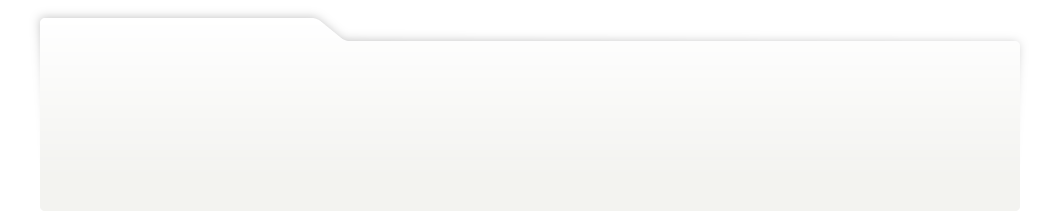
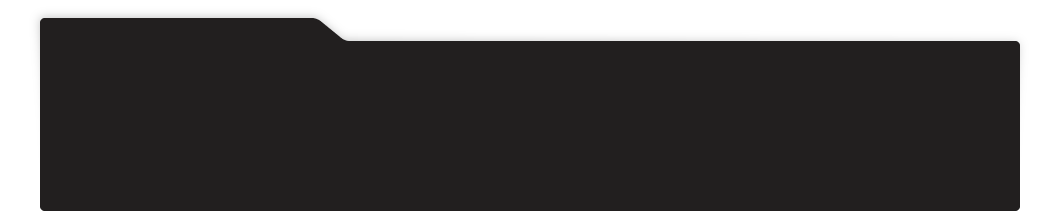
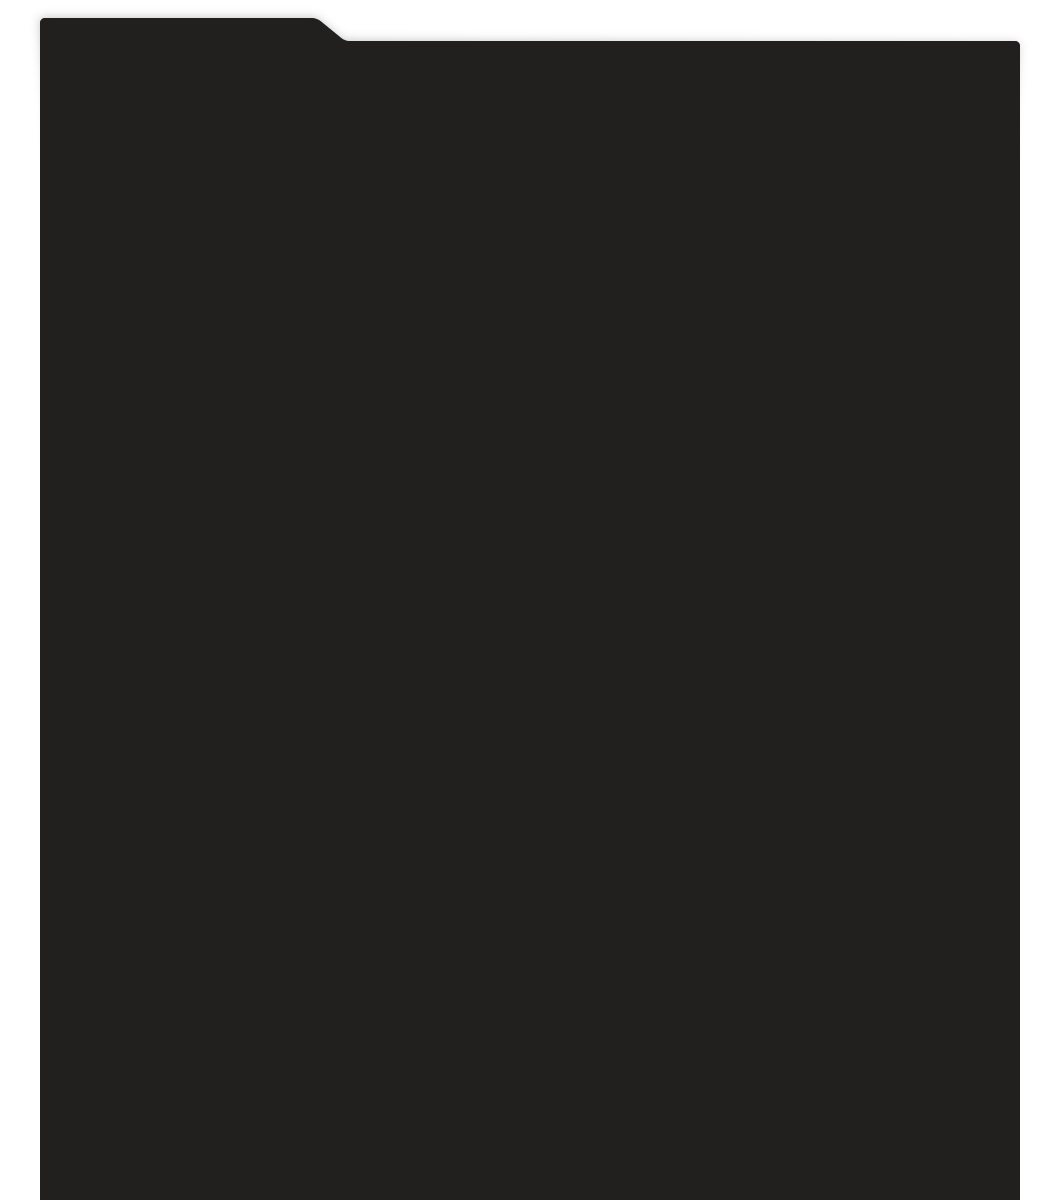
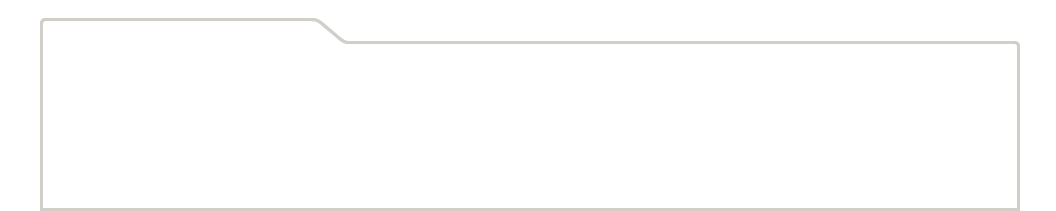
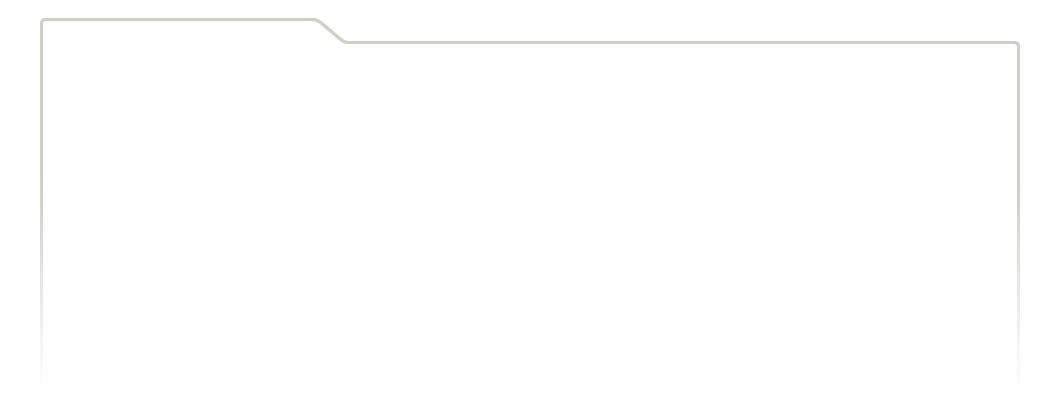
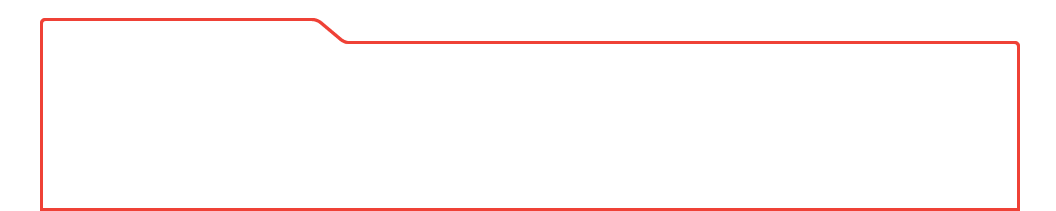
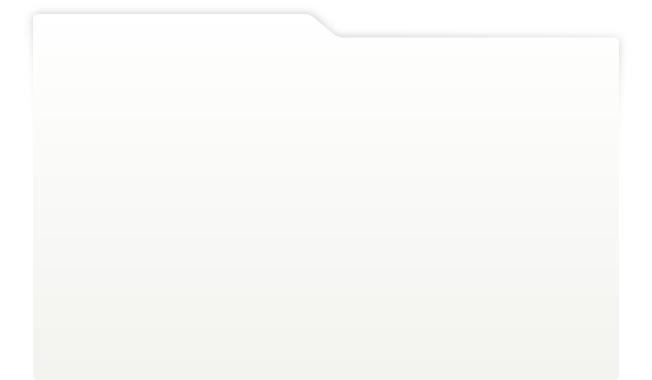
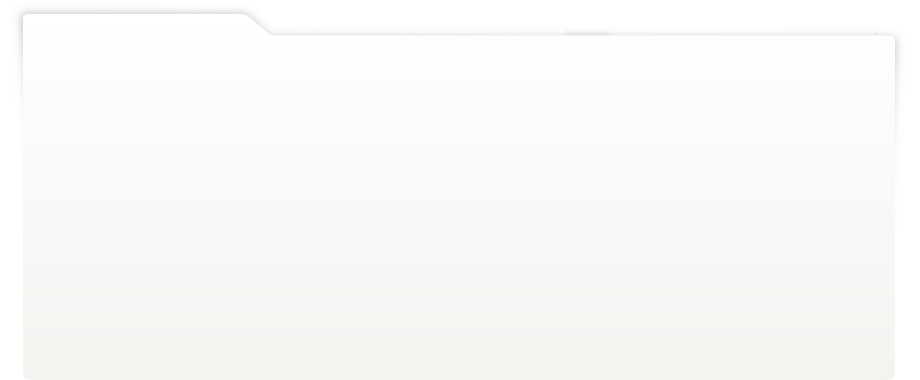
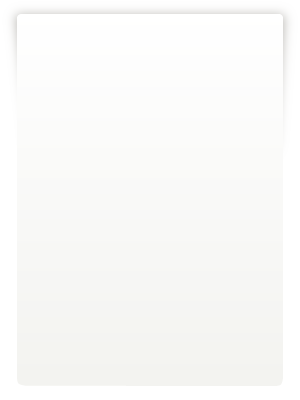
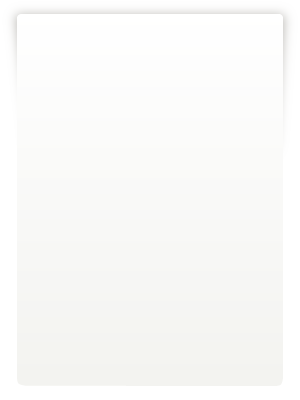
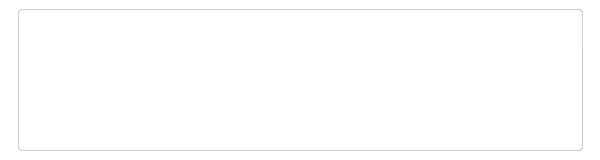
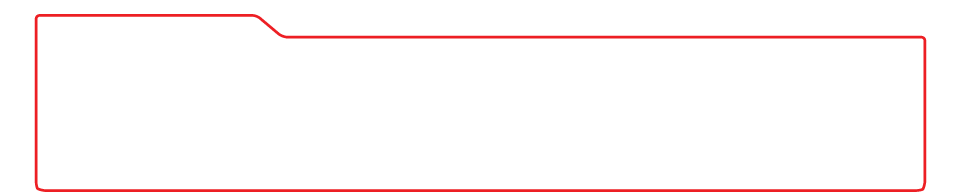
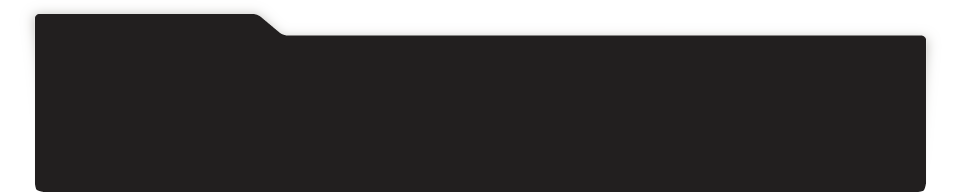
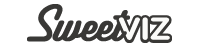
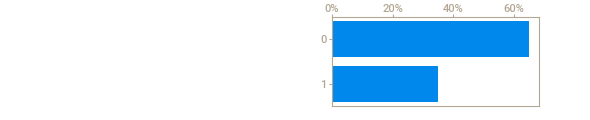
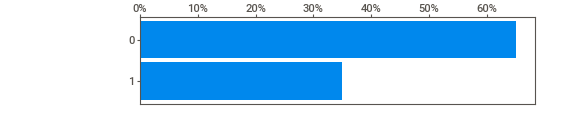
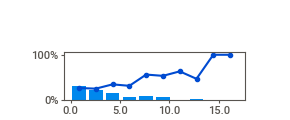
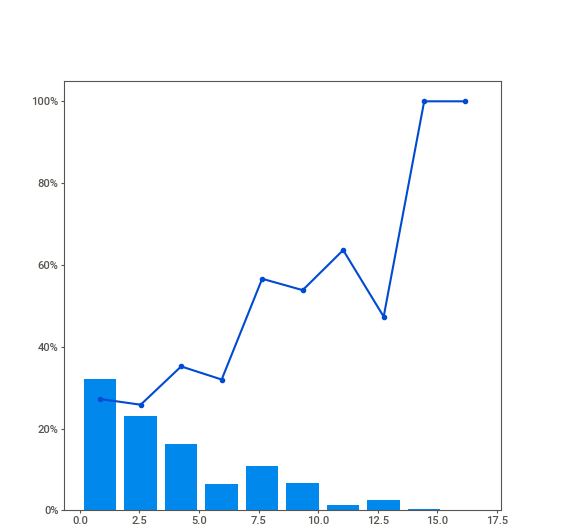
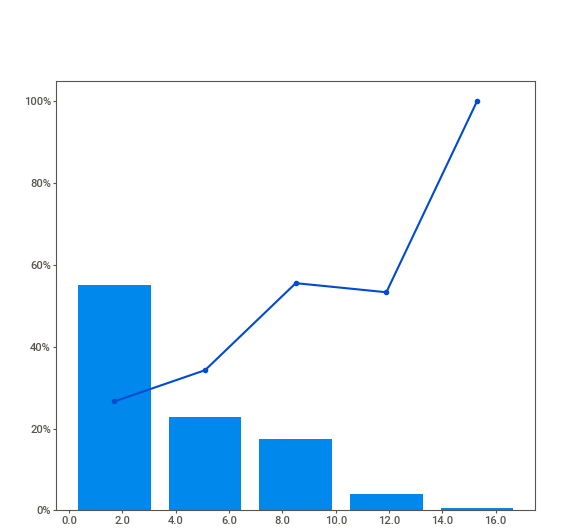
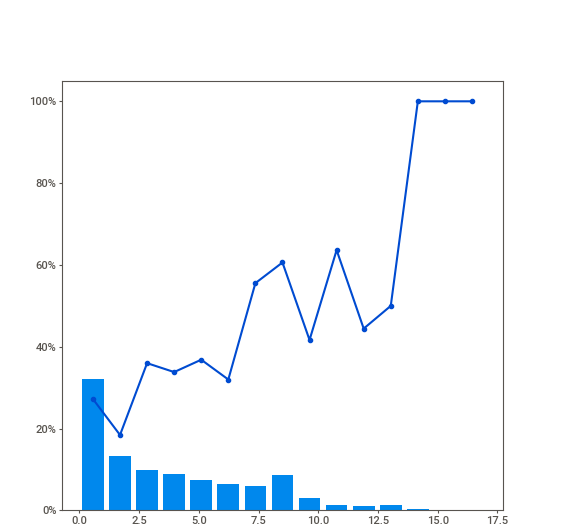
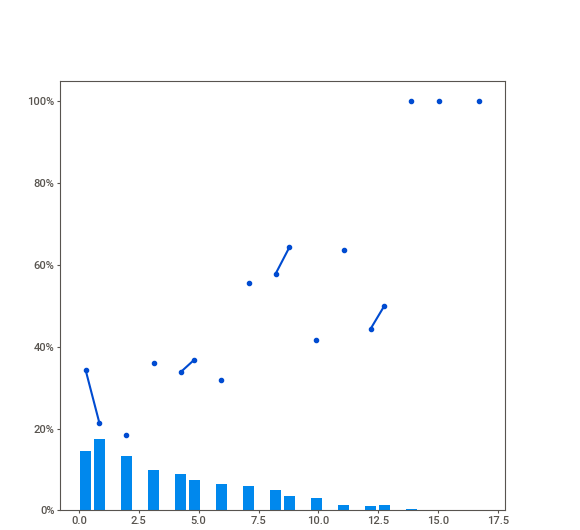
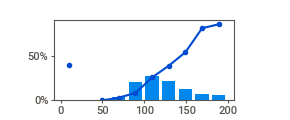
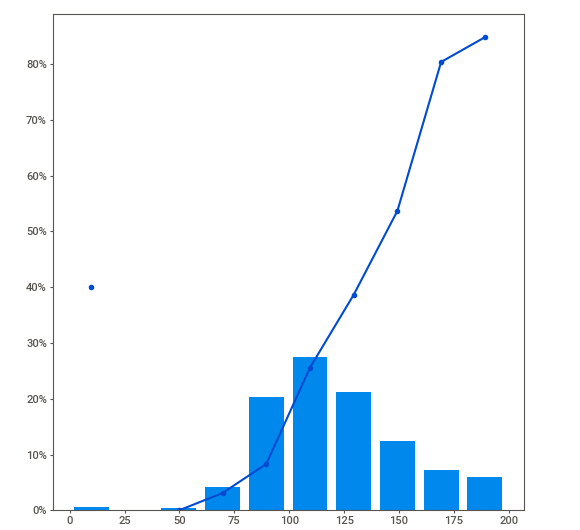
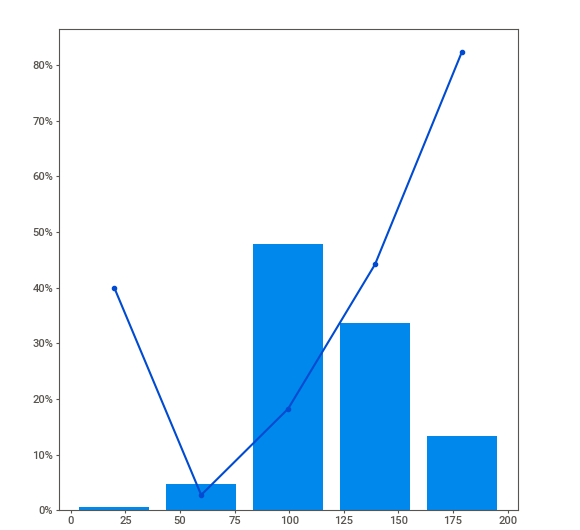
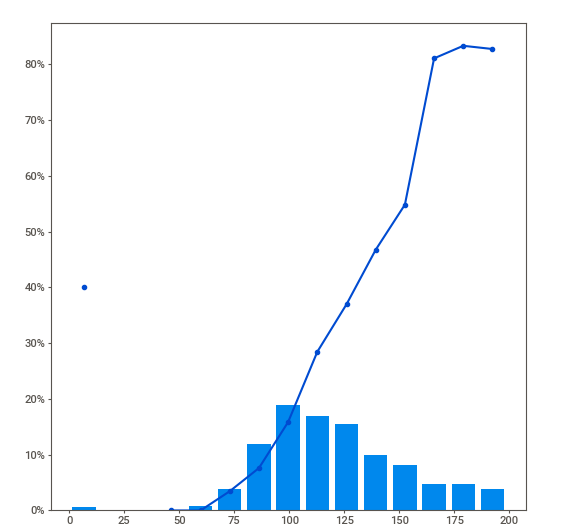
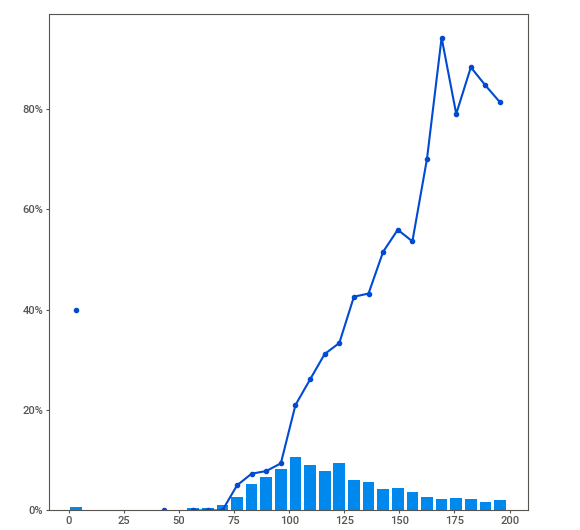
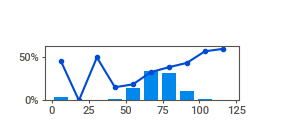
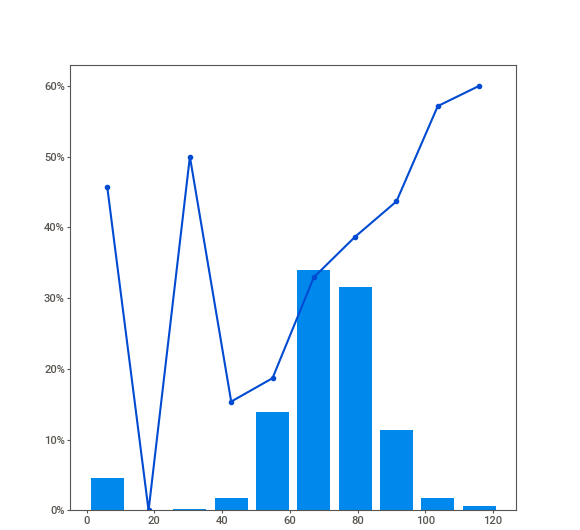
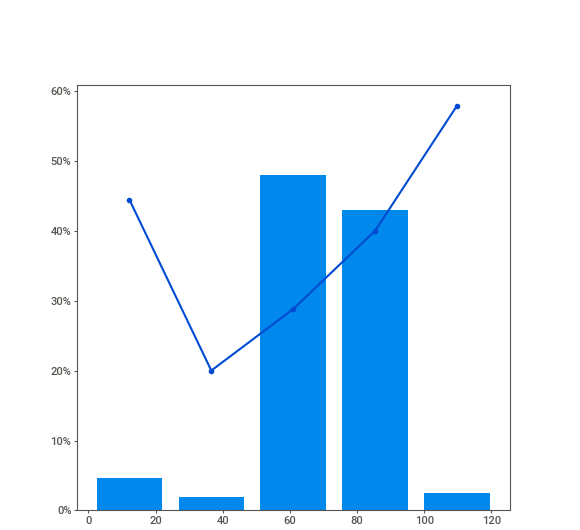
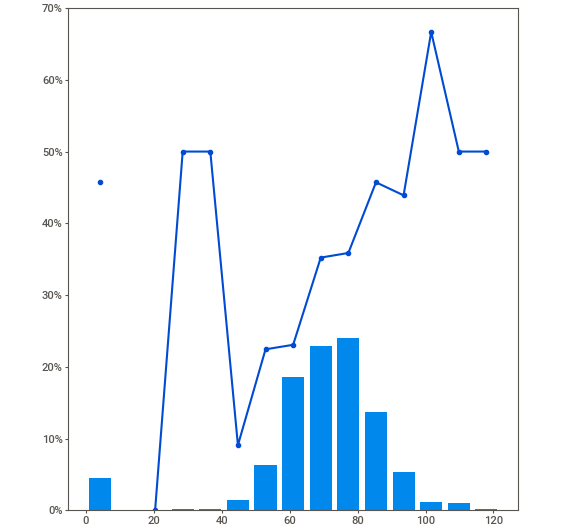
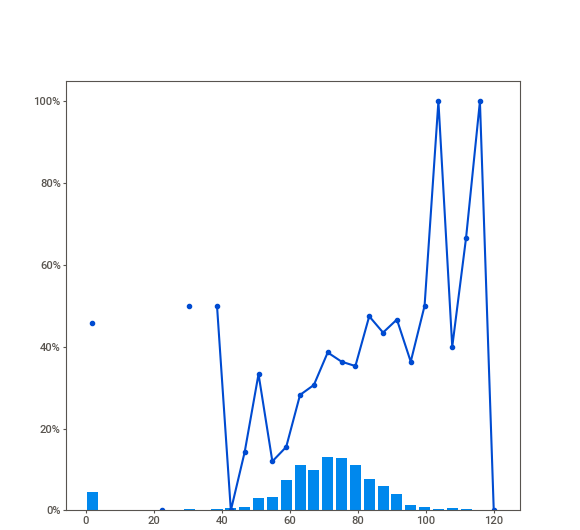
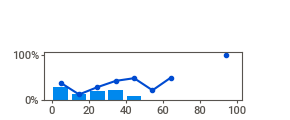
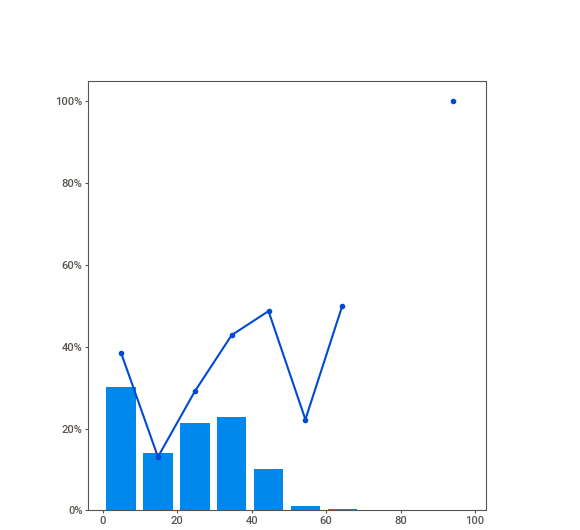
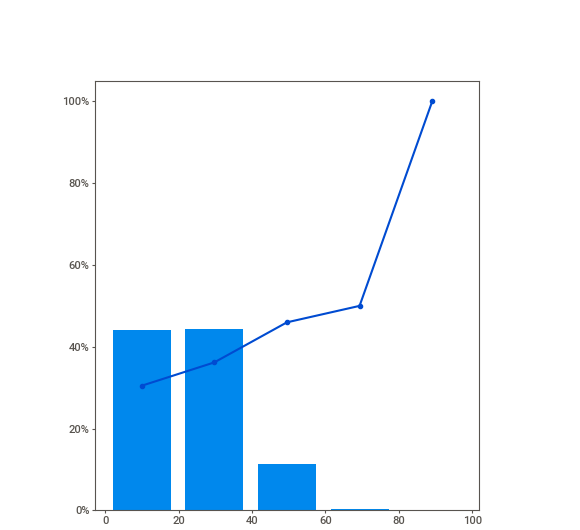
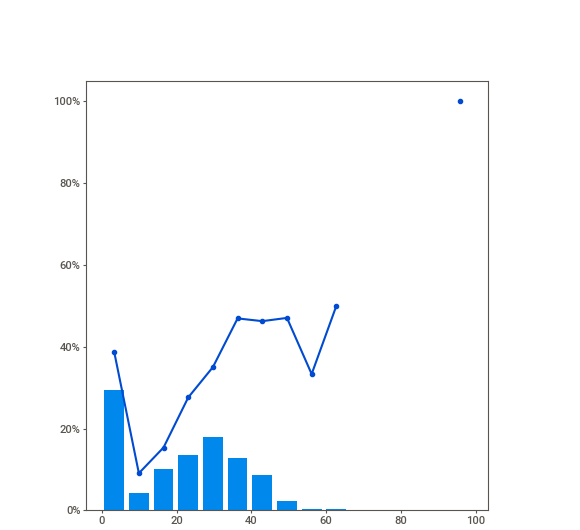
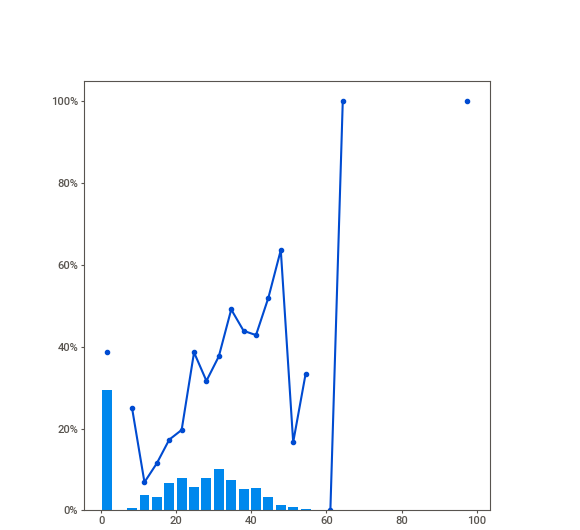
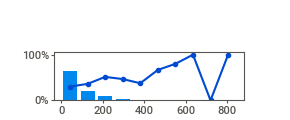
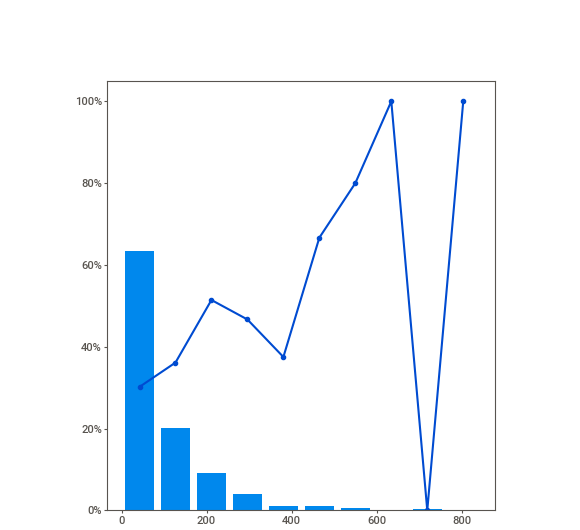
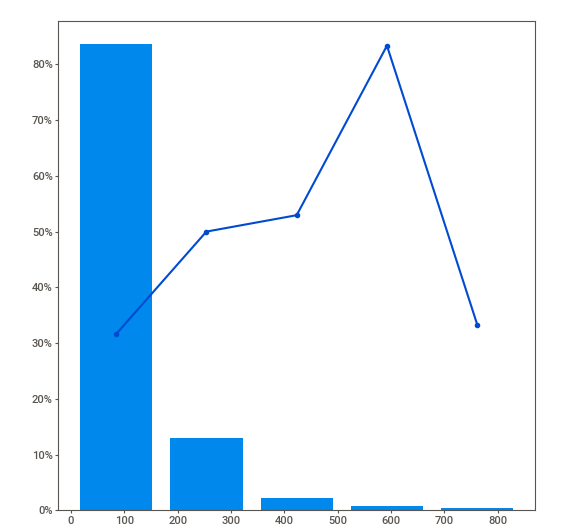
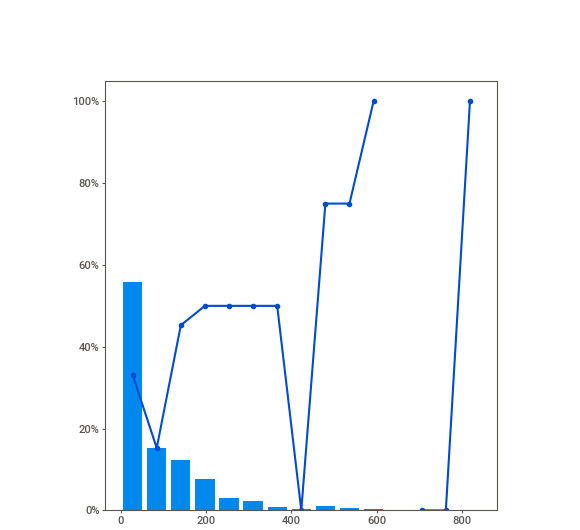
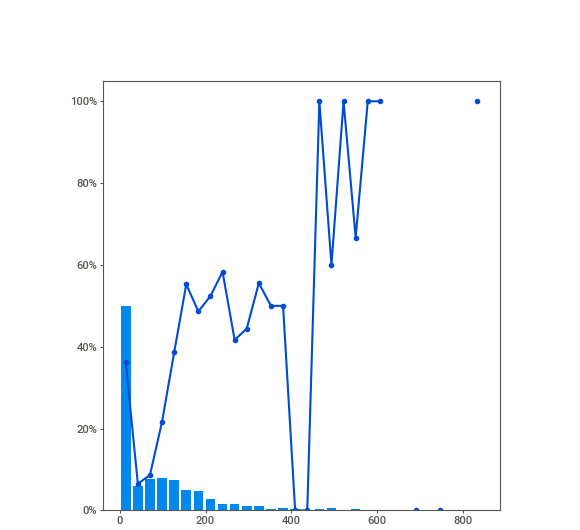
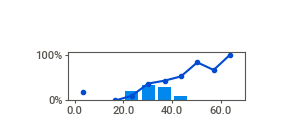
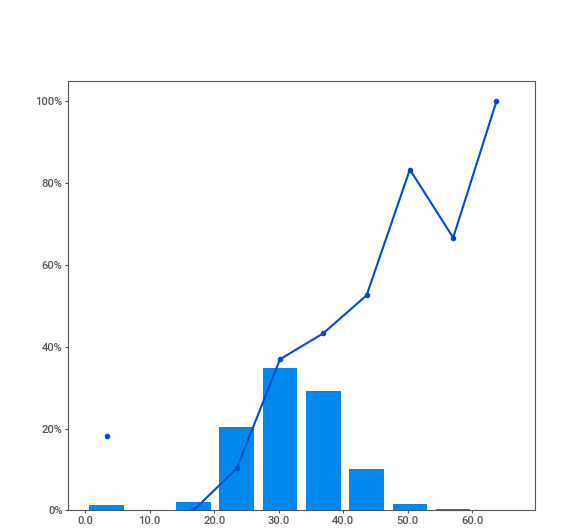
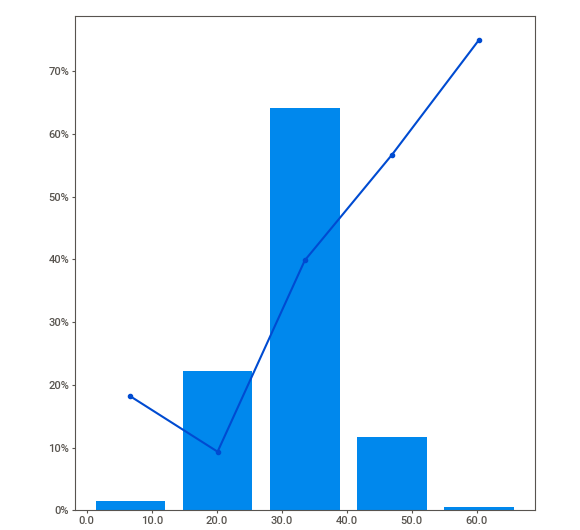
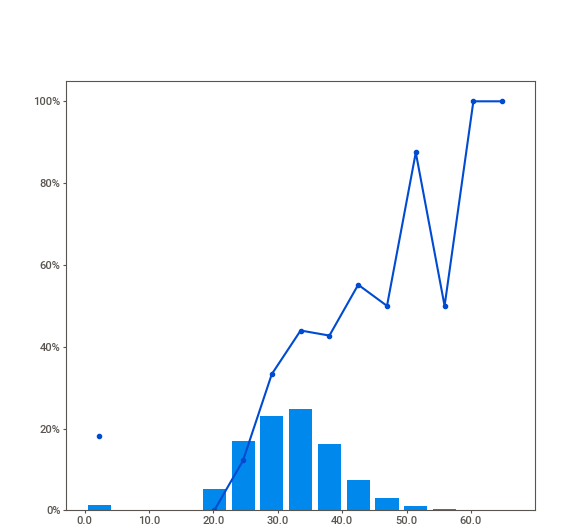
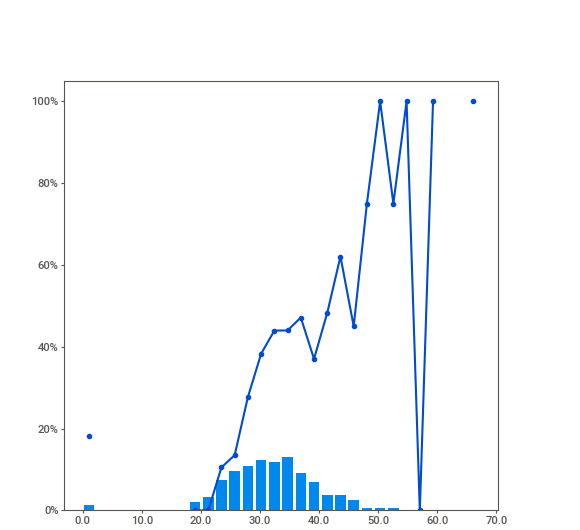
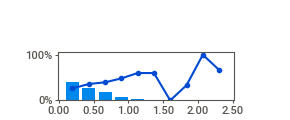
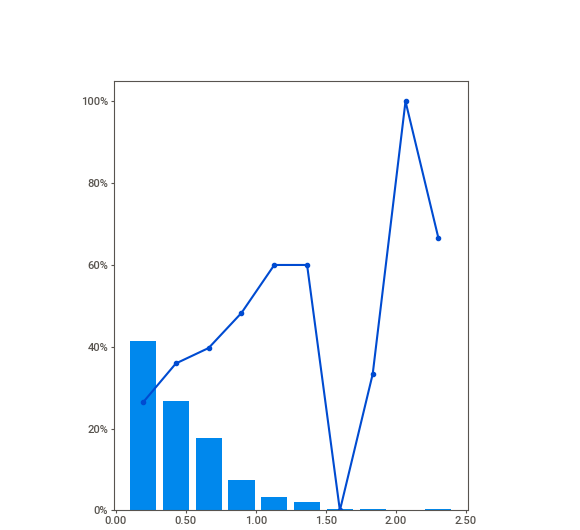
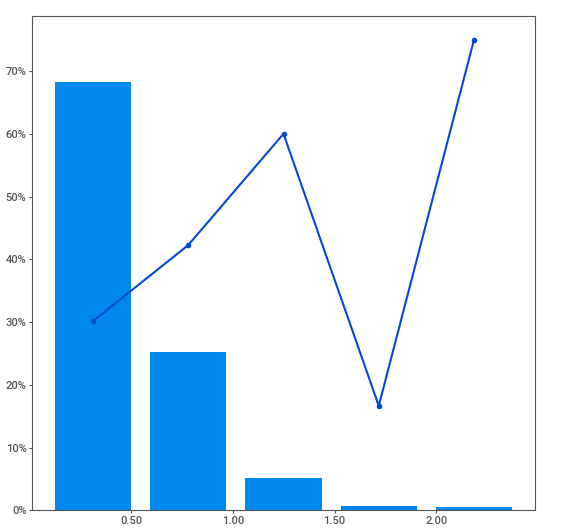
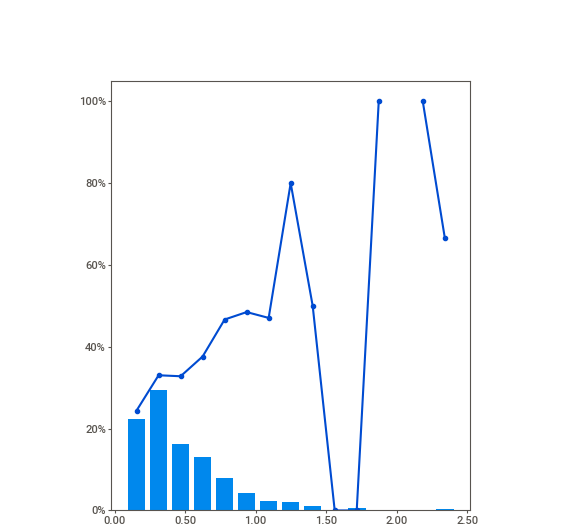
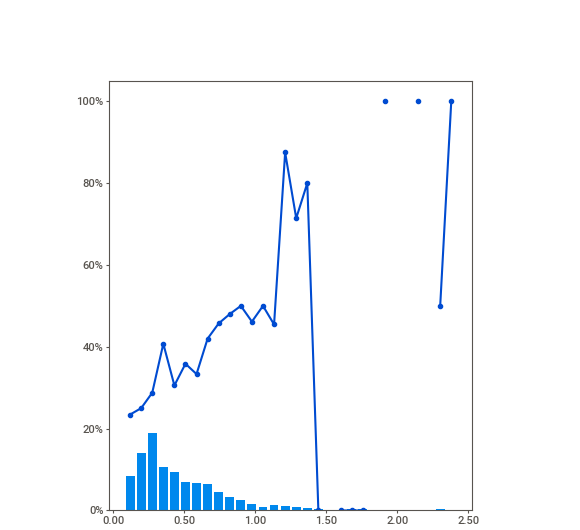
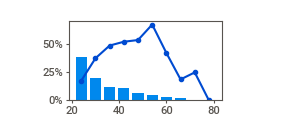
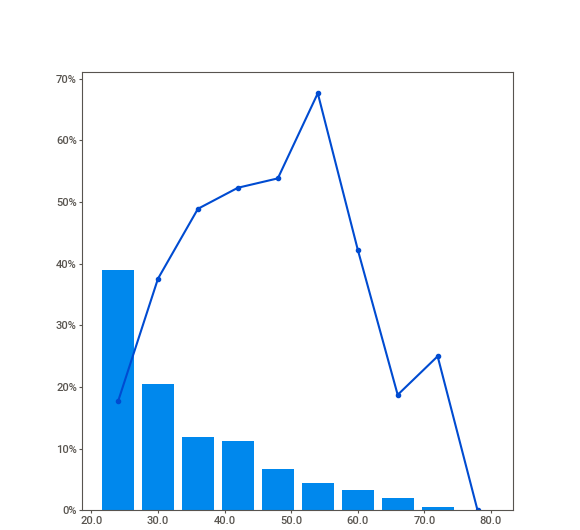
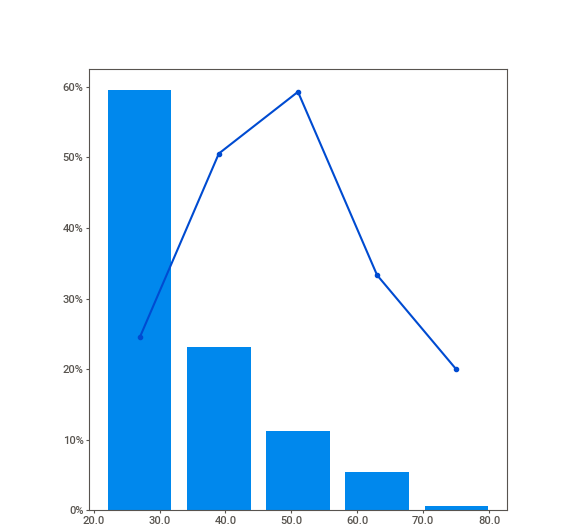
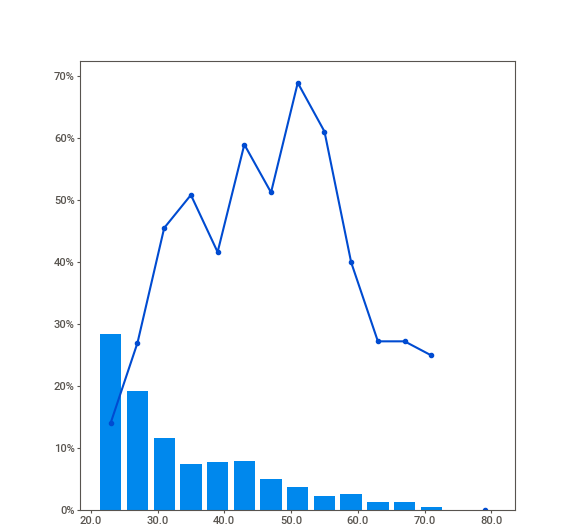
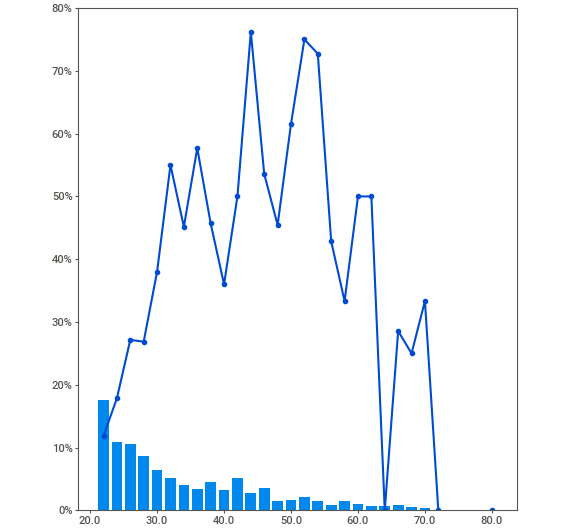
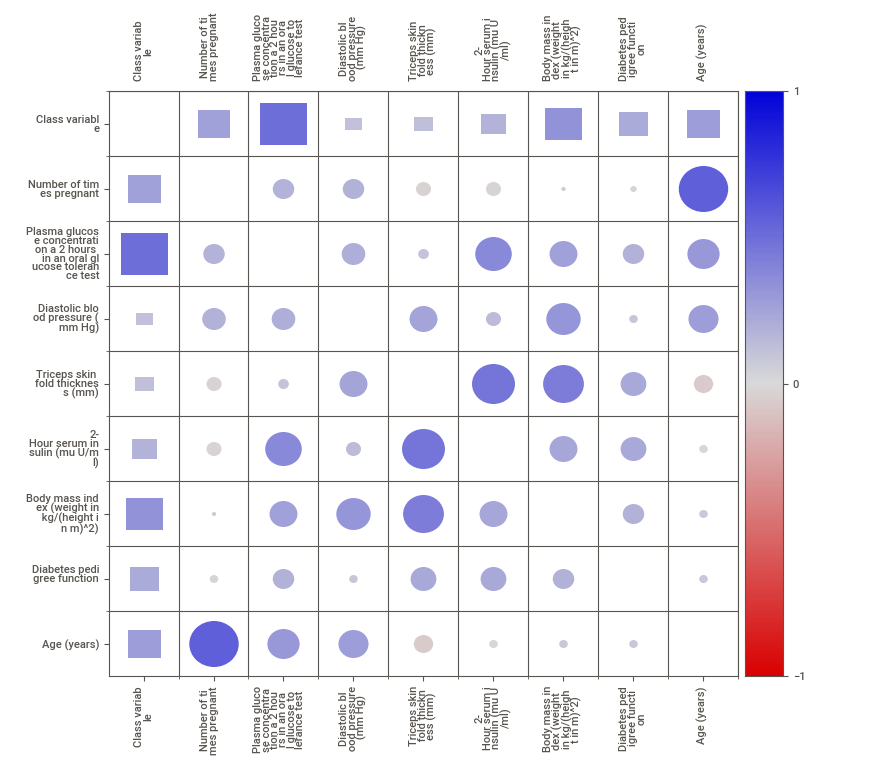
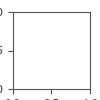

In [3]:
import sweetviz as sv

reporte = sv.analyze(data, target_feat='Class variable')
reporte.show_notebook()
# reporte.show_html('mi_reporte.html')  # Guarda el reporte

**Análisis**:

Se observa que la tabla no tiene valores nulos, la variable objetivo tiene un ligero desbalance (65% de los pacientes no tienen diabetes frente a 35% que si lo tienen). La variable objetivo se relaciona más con las variables: concentración de glucosa, índice de masa corporal, edad y número de veces embarazada.

En seguida el análisis específico para cada variable explicativa de la diabetes:

1. `Número de veces embarazada`: Entre más veces la mujer haya sido embarazada aumenta la tasa de casos de diabetes. Lo más común es que una mujer no haya tenido embarazos, sin embargo, observamos que hay un caso con 17 embarazos (esta mujer tiene diabetes).
2. `Concentración de glucosa`: blablablabla

### Ejercicio 1 (10 puntos)

> a. Continúe el análisis univariado para las demás variables

> b. Realice un análisis de acuerdo a la correlación

1. a) 

**Number of times pregnant**
Mayor número de embarazos se asocia a:
-Incremento de riesgo de diabetes 
-Posible impacto en resistencia a la insulina
El riesgo no crece proporcionalmente después de cierto número

**Plasma glucose concentration**
-Variable con alto poder discriminativo
-Distribución casi normal, ligeramente sesgada a la derecha (predictor mas fuerte de diabetes)
-Rango glucosa < 100 --> Normal
-Rango glucosa 100 - 125 --> Prediab
-Rango glucosa > 125 --> Diabetes

**Diastolic blood pressure**
-Concentración en rango normal-alto
-Algunos valores extremos (hipertensión)
-Los valores 0 NO son fisiológicamente posibles (missing values)
-Poder predictivo, medio

**Triceps skin fold thickness**
indicador mide grasa subcutánea:
30% son ceros, lo q indica una alta contaminación por valores invalidos
Interpretación segun el grosor de la grasa subcutanea:
- <10 mm -->     Bajo
- De 10 - 25 --> Normal
- > 25 mm -->    Alto (sobrepeso)

**2-hour serum insulin**
-49% ceros → esto NO es real clínicamente
-15–60 µU/mL--> Normal
>100 --> Hiperinsulinemia
>300 --> Sospecha patologica severa

**Body Mass Index (BMI)**
-La población está en promedio en obesidad
-Muy pocos casos en rango normal (<25)
-Hay alta presencia de riesgo metabólico y de presentar diabetes

**Diabetes pedigree function**
-La mayoría de personas tiene bajo a moderado riesgo genético
-Solo unos pocos tienen riesgo hereditario alto
-Los valores altos indican historia familiar fuerte de diabetes pero no explica por si solo el problema

**Age (years)**
-Pico principal entre 20 y 35 años
-Disminución gradual después de los 40
-Muy pocos casos >60

1. b)

Glucosa--> La glucosa explica casi la mitad (47%) de la variabilidad del target, es el mejor separador entre diabéticos y no diabéticos

BMI--> La obesidad tiene un impacto claro en la diabetes, pero no es suficiente por sí sola

Edad --> A mayor edad, mayor probabilidad pero con bastante solapamiento (La edad aumenta el riesgo, pero no lo define)

Embarazos --> Es una variable “proxy”, no causal directa

Pedigree --> La genética influye, pero menos de lo esperado

Insulina --> Mucho ruido con 49% de ceros. Deberia ser una variable fuerte

Skin Thickness --> ucho ruido con 30% de ceros

Presión diastólica --> Realmente poco relevante


Escriba su análisis aquí

## 3. Configuración PyCaret

Esta función inicializa el entorno de entrenamiento y crea la canalización de transformación. La función de configuración debe llamarse antes de ejecutar cualquier otra función. Toma dos parámetros obligatorios: `data` y `target`. Todos los demás parámetros son opcionales.

Puede especificar el session_id para que la división de los datos en entrenamiento y testeo permanezca fijo.

In [4]:
from pycaret import classification

s = classification.setup(
    data,
    target = 'Class variable',
    session_id=1234,
    normalize=True
)

,Description,Value
0,Session id,1234
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


Cuando se ejecuta la configuración, el algoritmo de inferencia de PyCaret inferirá automáticamente los tipos de datos para todas las variables en función de ciertas propiedades.

El tipo de datos debe inferirse correctamente, pero no siempre es así.

Asegurarse de que los tipos de datos sean correctos es realmente importante en PyCaret, ya que realiza automáticamente múltiples tareas de preprocesamiento específicas del tipo que son imprescindibles para los modelos de aprendizaje automático.


Alternativamente, también puede usar los parámetros `numeric_features` y `categorical_features` en la configuración para predefinir los tipos de datos.

### Ejercicio 2 (10 puntos)

1. Cuál es el tamaño de los datos de entrenamiento y testeo?
2. Consulte para qué sirve dividir los datos de esta manera?


Escriba la respuesta a las dos preguntas aquí
1.  

**Datos totales:** 768 registros

**Train** (entrenamiento): 537 registros

-Aprende relaciones

-Ajusta parámetros

-Detecta patrones

**Test** (prueba): 231 registros

-Se usa solo para evaluar

2. 

Entrenar el modelo (aprender patrones)

Evaluar el modelo (ver si funciona)

En el test se utiliza la media y la varianza del entrenamiento por que estos son datos desconocidos.

In [5]:
# Para ver como quedaron transformados los datos, use esto:
X_train = classification.get_config('X_train_transformed')
X_train.head(5)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
618,1.592314,-0.257406,0.645185,0.214474,-0.682440,-0.451845,2.274028,1.377543
422,-1.152213,-0.573281,-0.251101,1.562955,-0.002047,1.111058,0.031868,-1.029872
683,0.067577,0.153232,0.545597,-1.256596,-0.682440,0.064921,0.145972,-0.531786
609,-0.847266,-0.288993,-0.350688,-0.459766,0.905144,-0.981215,-0.989371,-0.863843
200,-1.152213,-0.225818,0.545597,-0.275883,-0.682440,-0.098931,1.110159,-1.029872


In [6]:
# Para ver como quedaron transformados los datos, use esto:
X_test = classification.get_config('X_test_transformed')
X_test.head(5)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years)
610,-0.237371,-0.446931,-0.749037,0.030590,0.695792,-0.111535,-0.550067,-0.780829
399,-0.237371,2.301182,0.047661,0.643536,-0.682440,0.392627,-0.695551,-0.697815
653,-0.542318,-0.004706,-0.749037,-1.256596,-0.682440,-0.628302,-0.085090,-0.531786
421,-0.542318,-0.825981,-0.051926,-0.153294,-0.019493,-0.729134,0.217288,-1.029872
79,-0.542318,-0.257406,-0.151514,0.091885,-0.682440,-0.855175,-0.507278,-0.780829


### Ejercicio 3 (10 puntos)

1. Verifique que las variables de entrenamiento (X_train) quedaron correctamente normalizadas. Su media debería ser cero y la varianza 1
2. Por qué no sucede lo mismo con X_test. Qué puede estar pasando?

In [7]:
# ------------------------------------------
# Verifique media 0 y var 1 para X_train (aprox. entre 1 a 5 líneas de código)
# Obtener X_train transformado
X_train = classification.get_config('X_train_transformed')

# Verificar media y varianza por columna
print("Media:\n", X_train.mean())
print("\nVarianza:\n", X_train.var())

# ------------------------------------------

Media:
 Number of times pregnant                                                    1.653964e-17
Plasma glucose concentration a 2 hours in an oral glucose tolerance test   -1.918598e-16
Diastolic blood pressure (mm Hg)                                            7.442836e-18
Triceps skin fold thickness (mm)                                           -1.653964e-17
2-Hour serum insulin (mu U/ml)                                             -7.277440e-17
Body mass index (weight in kg/(height in m)^2)                              6.615854e-17
Diabetes pedigree function                                                  6.946647e-17
Age (years)                                                                 1.885518e-16
dtype: float64

Varianza:
 Number of times pregnant                                                    1.001866
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    1.001866
Diastolic blood pressure (mm Hg)                                            1.00186

In [8]:
# ------------------------------------------
# calcule media y var para X_test (aprox. entre 1 a 5 líneas de código)
# Obtener X_test transformado
X_test = classification.get_config('X_test_transformed')

# Calcular media y varianza
print("Media:\n", X_test.mean())
print("\nVarianza:\n", X_test.var())
# ------------------------------------------

Media:
 Number of times pregnant                                                    0.067577
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    0.078297
Diastolic blood pressure (mm Hg)                                            0.010370
Triceps skin fold thickness (mm)                                            0.007240
2-Hour serum insulin (mu U/ml)                                              0.045382
Body mass index (weight in kg/(height in m)^2)                              0.087019
Diabetes pedigree function                                                 -0.122841
Age (years)                                                                -0.045560
dtype: float64

Varianza:
 Number of times pregnant                                                    1.183032
Plasma glucose concentration a 2 hours in an oral glucose tolerance test    1.062287
Diastolic blood pressure (mm Hg)                                            0.762832
Triceps skin fold thickness (m

Realice su análisis aquí

Los resultados muestran que el conjunto de entrenamiento fue correctamente normalizado utilizando z-score, ya que todas las variables presentan medias cercanas a cero y varianzas cercanas a uno. Esto indica que las variables han sido estandarizadas en la misma escala, lo que mejora la estabilidad y el rendimiento de los modelos de aprendizaje automático, evitando que variables con mayor magnitud dominen el entrenamiento.

Los resultados muestran que el conjunto de prueba (X_test) no presenta una media de cero ni una varianza de uno, a diferencia del conjunto de entrenamiento. Esto es esperado, ya que X_test es transformado utilizando los parámetros (media y desviación estándar) calculados en X_train. Las diferencias observadas reflejan variaciones naturales en la distribución de los datos de prueba, lo cual es deseable porque permite evaluar la capacidad de generalización del modelo en datos no vistos

## 4. Comparar modelos

Esta función entrena y evalúa el rendimiento de todos los estimadores (modelos) disponibles en la biblioteca de modelos mediante validación cruzada.

El resultado de esta función es una tabla de puntuación con puntuaciones medias validadas de forma cruzada. Se puede acceder a las métricas evaluadas durante CV mediante la función `get_metrics`. Las métricas personalizadas se pueden agregar o eliminar mediante las funciones `add_metric` y `remove_metric`.

In [9]:
mejor_modelo_auc = classification.compare_models(sort='AUC')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,00:59:23
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Logistic Regression


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
gbc,Gradient Boosting Classifier,0.7503,0.8378,0.5827,0.6776,0.6117,0.4326,0.4443,0.1290
ridge,Ridge Classifier,0.7636,0.8289,0.5193,0.7331,0.6013,0.4419,0.4589,0.0330
lda,Linear Discriminant Analysis,0.7654,0.8289,0.5298,0.7298,0.6075,0.4480,0.4633,0.0300
lr,Logistic Regression,0.7672,0.8286,0.5351,0.7325,0.6129,0.4535,0.4682,0.9290
rf,Random Forest Classifier,0.7597,0.8221,0.5825,0.6974,0.6251,0.4521,0.4625,0.1800
et,Extra Trees Classifier,0.7635,0.8205,0.5673,0.7177,0.6241,0.4561,0.4693,0.1350
lightgbm,Light Gradient Boosting Machine,0.7280,0.8090,0.5570,0.6317,0.5824,0.3852,0.3928,0.1780
nb,Naive Bayes,0.7430,0.7996,0.5728,0.6489,0.6035,0.4165,0.4210,0.0250
qda,Quadratic Discriminant Analysis,0.7335,0.7946,0.5287,0.6443,0.5757,0.3860,0.3927,0.0330
svm,SVM - Linear Kernel,0.7524,0.7914,0.6319,0.6656,0.6272,0.4471,0.4634,0.0280


In [20]:
print(mejor_modelo_auc)

GradientBoostingClassifier(ccp_alpha=0.0, criterion='friedman_mse', init=None,
                           learning_rate=0.1, loss='log_loss', max_depth=3,
                           max_features=None, max_leaf_nodes=None,
                           min_impurity_decrease=0.0, min_samples_leaf=1,
                           min_samples_split=2, min_weight_fraction_leaf=0.0,
                           n_estimators=100, n_iter_no_change=None,
                           random_state=1234, subsample=1.0, tol=0.0001,
                           validation_fraction=0.1, verbose=0,
                           warm_start=False)


## 5. Analizar el mejor modelo

Esta función analiza el rendimiento de un modelo entrenado en los datos de testeo

In [ ]:
classification.evaluate_model(mejor_modelo_auc)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Ejercicio 4 (10 puntos)

El método anterior nos permite obtener el mejor modelo, sin embargo algunas veces necesitamos tomar el modelo por su simplicidad más que por su rendimiento. Para esto debemos utilizar el método `classification.create_model`.

Por ejemplo para el modelo `randomforest` utilizamos:
`model_rf = classification.create_model('rf')`

1. Del listado tome el modelo de regresión logística y asígnelo a `modelo_regresion_logistica`
2. Luego evalúe con el botón `Learning Curve` frente al modelo `mejor_modelo` realizado anteriormente. Consulte el significado de esta curva y SOLO TENIENDO EN CUENTA ESTO, explique cual modelo es considerado mejor.

R/: 
**Learning Curve**: Es una grafica que compara los resultados del training y el test, en función de la cantidad de datos y sirve para ver que tan bien aprende el modelo. Si las curvas estan separadas, muestra un modelo complejo que memoriza los datos pero pierde capacidad predictiva real. Cuando las curvas estan cerca o solapadas muestra un modelo mas estable.

El modelo de `regresión logística` es considerado mejor, ya que presenta curvas de entrenamiento y validación cercanas entre sí, lo que indica buena capacidad de generalización y bajo sobreajuste. En contraste, el modelo `GBC` que muestra una gran diferencia entre ambas curvas, evidenciando sobreajustes significativos.

In [ ]:
# ------------------------------------------
# 1. Cree el modelo y evalúelo (2 líneas de código)
modelo_regresion_logistica = classification.create_model("lr")
classification.evaluate_model(modelo_regresion_logistica)
# ------------------------------------------

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7037,0.8421,0.3684,0.6364,0.4667,0.2812,0.3013
1,0.7222,0.8226,0.5789,0.6111,0.5946,0.3836,0.3839
2,0.7222,0.7038,0.4211,0.6667,0.5161,0.3350,0.3524
3,0.8519,0.8992,0.7368,0.8235,0.7778,0.6672,0.6695
4,0.8148,0.7895,0.5789,0.8462,0.6875,0.5624,0.5828
5,0.7407,0.8511,0.4737,0.6923,0.5625,0.3874,0.4014
6,0.8148,0.8827,0.5263,0.9091,0.6667,0.5507,0.5902
7,0.8491,0.9032,0.6667,0.8571,0.7500,0.6443,0.6547
8,0.7547,0.8460,0.4444,0.7273,0.5517,0.3961,0.4189


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [84]:
# mejor_modelo = mejor_modelo_auc  # Para usar el modelo con mejor AUC
mejor_modelo = modelo_regresion_logistica  # Descomente para usar el modelo de regresión logística

2. Analice la learning curve del mejor modelo auc vs el modelo de regresión logística. Explique cual es mejor aqui

R/:
El modelo de `regresión logística` es considerado mejor, ya que presenta curvas de entrenamiento y validación cercanas entre sí, lo que indica buena capacidad de generalización y bajo sobreajuste. En contraste, el modelo `GBC` que muestra una gran diferencia entre ambas curvas, evidenciando sobreajustes significativos.


## 6. Predicciones

In [91]:
# Predicciones datos de test (raw_score=True para obtener probabilidades)
data_test_pred = classification.predict_model(mejor_modelo, raw_score=True)
data_test_pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.8052,0.8415,0.6420,0.7647,0.6980,0.5558,0.5605


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score_0,prediction_score_1
610,3,106,54,21,158,30.900000,0.292,24,0,0,0.8417,0.1583
399,3,193,70,31,0,34.900002,0.241,25,1,1,0.1539,0.8461
653,2,120,54,0,0,26.799999,0.455,27,0,0,0.7953,0.2047
421,2,94,68,18,76,26.000000,0.561,21,0,0,0.9241,0.0759
79,2,112,66,22,0,25.000000,0.307,24,0,0,0.8827,0.1173
...,...,...,...,...,...,...,...,...,...,...,...,...
581,6,109,60,27,0,25.000000,0.206,27,0,0,0.8296,0.1704
655,2,155,52,27,540,38.700001,0.240,25,1,0,0.5052,0.4948
170,6,102,82,0,0,30.799999,0.180,36,1,0,0.8428,0.1572
676,9,156,86,0,0,24.799999,0.230,53,1,1,0.4737,0.5263


In [92]:
# Predicciones datos completos
data_pred = classification.predict_model(mejor_modelo, data=data, raw_score=True)
data_pred

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Logistic Regression,0.7786,0.8372,0.5709,0.7356,0.6429,0.4861,0.4943


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score_0,prediction_score_1
0,6,148,72,35,0,33.599998,0.627,50,1,1,0.2826,0.7174
1,1,85,66,29,0,26.600000,0.351,31,0,0,0.9430,0.0570
2,8,183,64,0,0,23.299999,0.672,32,1,1,0.2090,0.7910
3,1,89,66,23,94,28.100000,0.167,21,0,0,0.9500,0.0500
4,0,137,40,35,168,43.099998,2.288,33,1,1,0.0979,0.9021
...,...,...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.900002,0.171,63,0,0,0.7008,0.2992
764,2,122,70,27,0,36.799999,0.340,27,0,0,0.6437,0.3563
765,5,121,72,23,112,26.200001,0.245,30,0,0,0.8173,0.1827
766,1,126,60,0,0,30.100000,0.349,47,1,0,0.7363,0.2637


## Ejercicio 5 (10 puntos)

Calcule la probabilidad y la predicción que una persona tenga diabetes con las siguientes características:

1. **Número de embarazos**: 2
2. **Glucosa en plasma**: 100
3. **Presión arterial diastólica**: 50
4. **Grosor del pliegue cutáneo del tríceps**: 50
5. **Insulina sérica de 2 horas**: 100
6. **Índice de masa corporal (IMC)**: 50
7. **Función del pedigrí de la diabetes**: 1
8. **Edad**: 40

In [93]:


new_data = pd.DataFrame([{
    'Number of times pregnant': 2,
    'Plasma glucose concentration a 2 hours in an oral glucose tolerance test': 100,
    'Diastolic blood pressure (mm Hg)': 50,
    'Triceps skin fold thickness (mm)': 50,
    '2-Hour serum insulin (mu U/ml)': 100,
    'Body mass index (weight in kg/(height in m)^2)': 50,
    'Diabetes pedigree function': 1,
    'Age (years)': 40
}])


In [94]:
# ------------------------------------------
# 1. Calcule la probabilidad (~2 líneas de código)

from pycaret.classification import predict_model

pred = predict_model(mejor_modelo, data=new_data)
print(pred)

# ------------------------------------------

   Number of times pregnant  \
0                         2   

   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  \
0                                                100                          

   Diastolic blood pressure (mm Hg)  Triceps skin fold thickness (mm)  \
0                                50                                50   

   2-Hour serum insulin (mu U/ml)  \
0                             100   

   Body mass index (weight in kg/(height in m)^2)  Diabetes pedigree function  \
0                                              50                           1   

   Age (years)  prediction_label  prediction_score  
0           40                 1            0.6786  


El modelo de "regresión logística" clasifica a la persona como diabetica (1), con una estimación del 68% de probabilidad.
El modelo "mejor_modelo_AUC" tambien lo clasifica como diabetico, con una probabilidad más alta (73%). Pero como vimos en la comparación de las gráficas "learning curve" esta ultima presenta sobreajustes.

## 7. Guardar y cargar modelo

In [95]:
classification.save_model(mejor_modelo, 'mi_mejor_modelo')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Number of times pregnant',
                                              'Plasma glucose concentration a 2 '
                                              'hours in an oral glucose '
                                              'tolerance test',
                                              'Diastolic blood pressure (mm Hg)',
                                              'Triceps skin fold thickness (mm)',
                                              '2-Hour serum insulin (mu U/ml)',
                                              'Body mass index (weight in '
                                              'kg/(height in m)^2)',
                                              'Diabetes pedigre...
                  TransformerWrapper(exclude=None, include=None,
                                     transformer=CleanC

In [96]:
modelo_cargado = classification.load_model('mi_mejor_modelo')
print(modelo_cargado)

Transformation Pipeline and Model Successfully Loaded
Pipeline(memory=FastMemory(location=/tmp/joblib),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Number of times pregnant',
                                             'Plasma glucose concentration a 2 '
                                             'hours in an oral glucose '
                                             'tolerance test',
                                             'Diastolic blood pressure (mm Hg)',
                                             'Triceps skin fold thickness (mm)',
                                             '2-Hour serum insulin (mu U/ml)',
                                             'Body mass index (weight in '
                                             'kg/(height in m)^2)',
                                             'Diab...
                 TransformerWrapper(exclude=None, include=None,
                

* Documentación Pycaret: https://pycaret.gitbook.io/docs/get-started/preprocessing
* Otra herramienta para hacer EDA: pandas profiling